# GUS01C: GeoTERYT Database

This notebook demonstrates the GeoTERYT database system for Polish administrative divisions.

## Overview
- Build database from harmonized TERYT data (from GUS01A)
- Load geometries from shapefiles (from GUS01B)
- Search and query functionality
- Geometry operations (merging, best geometry selection)
- Overlay operations (pre-1999 voivodeships)

In [ ]:
import os
import sys
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
            return p
    return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geospatial_root = repo_root.parent.parent / 'Data' / 'Geospatial'
geometry_root = repo_root.parent.parent / 'Data' / 'Geospatial' / 'geometry'
gus_root = Path(os.getcwd()).parent.parent.parent.parent / "Data" / "GUS"

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# Import local toolkit
import local_utility_functions as luf
import geoTERYT_db as gtdb

print(f"Repo root: {repo_root}")
print(f"GUS root: {gus_root}")
print(f"Geometry root: {geometry_root}")

Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
GUS root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/GUS
Geometry root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geometry


## 1. Load Harmonized TERYT Data

Load the mega DataFrame created in GUS01A notebook.

In [ ]:
# Load the saved mega_df from GUS01A/GUS01B
mega_df = pd.read_csv(geospatial_root / "teryt_df_backup.csv", encoding="utf-8")

# Ensure proper formatting
v_tostring = np.vectorize(lambda x: str(x))
v_zero_pad = np.vectorize(lambda x, n: str(x).zfill(n))
mega_df['id'] = v_zero_pad(v_tostring(mega_df['id']), 7)

print(f"Loaded mega_df: {len(mega_df)} rows")
print(f"Years: {mega_df['year'].min()} - {mega_df['year'].max()}")
print(f"Columns: {list(mega_df.columns)}")
mega_df.head()

Loaded mega_df: 107346 rows
Years: 1999 - 2024
Columns: ['year', 'WOJ', 'POW', 'GMI', 'RODZ', 'id', 'NAZWA', 'NAZWA_DOD', 'level', 'kind', 'STAN_NA', 'if_changed', 'when_changed', 'notes']


,year,WOJ,POW,GMI,RODZ,id,NAZWA,NAZWA_DOD,level,kind,STAN_NA,if_changed,when_changed,notes
0,1999,2,0,0,0,0200000,DOLNOŚLĄSKIE,województwo,2,NaN,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}"
1,1999,2,1,0,0,0201000,bolesławiecki,powiat,5,NaN,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}"
2,1999,2,1,1,1,0201011,Bolesławiec,gmina miejska,6,urban,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}"
3,1999,2,1,2,2,0201022,Bolesławiec,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}"
4,1999,2,1,3,2,0201032,Gromadka,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}"


## 2. Load Geometry Files

In [ ]:
import re

# Scan for geometry files
geometry_files = [f for f in os.listdir(geometry_root) if not f.startswith('.')]
geometry_paths = [geometry_root / f for f in geometry_files]

shape_files = []
for i in range(len(geometry_paths)):
    if geometry_paths[i].is_dir():
        dir_contents = os.listdir(geometry_paths[i])
        for file in dir_contents:
            if file.endswith('.shp'):
                shape_files.append(geometry_paths[i] / file)

shape_files.sort()
# Filter to gmina-level files
shape_files = [f for f in shape_files if 'Obszary' in f.name or 'gmin' in f.name]

print("Found shapefiles:")
for f in shape_files:
    print(f"  {f.parent.name}/{f.name}")

Found shapefiles:
  PRG_jednostki_administracyjne_2005/Obszary.shp
  PRG_jednostki_administracyjne_2006/Obszary.shp
  PRG_jednostki_administracyjne_2007/Obszary.shp
  PRG_jednostki_administracyjne_2008/Obszary.shp
  PRG_jednostki_administracyjne_2009/Obszary.shp
  PRG_jednostki_administracyjne_2010/Obszary.shp
  PRG_jednostki_administracyjne_2011/Obszary.shp
  PRG_jednostki_administracyjne_2012/Obszary_1992_region.shp
  PRG_jednostki_administracyjne_2015/gminy.shp
  PRG_jednostki_administracyjne_2016/gminy.shp
  PRG_jednostki_administracyjne_2017/gminy.shp
  PRG_jednostki_administracyjne_2018/gminy.shp
  PRG_jednostki_administracyjne_2021/A03_Granice_gmin.shp
  PRG_jednostki_administracyjne_2022/A03_Granice_gmin.shp
  PRG_jednostki_administracyjne_2023/A03_Granice_gmin.shp


In [ ]:
# Load all shapefiles into a dictionary
gdf_list = {}
for file in shape_files:
    key = str(file.parent)[-4:] + "_" + str(file.stem)
    try:
        gdf = gpd.read_file(file)
        gdf_list[key] = gdf
        print(f"Loaded {key}: {len(gdf)} features")
    except Exception as e:
        print(f"Error loading {key}: {e}")

print(f"\nTotal loaded: {len(gdf_list)} GeoDataFrames")

Loaded 2005_Obszary: 3175 features
Loaded 2006_Obszary: 3183 features
Loaded 2007_Obszary: 3183 features
Loaded 2008_Obszary: 3185 features
Loaded 2009_Obszary: 3190 features
Loaded 2010_Obszary: 3203 features
Loaded 2011_Obszary: 3209 features
Loaded 2012_Obszary_1992_region: 3209 features
Loaded 2015_gminy: 2481 features
Loaded 2016_gminy: 2481 features
Loaded 2017_gminy: 2478 features
Loaded 2018_gminy: 2478 features
Loaded 2021_A03_Granice_gmin: 2477 features
Loaded 2022_A03_Granice_gmin: 2477 features
Loaded 2023_A03_Granice_gmin: 2477 features

Total loaded: 15 GeoDataFrames


In [ ]:
# Prepare GeoDataFrames: standardize teryt column and CRS
for key in gdf_list:
    print(f"Processing {key}...")
    
    # Extract year from key
    match = re.search(r'\d{4}', key)
    if not match:
        continue
    year = int(match.group(0))
    
    # Standardize column names to lowercase
    gdf_list[key].columns = [col.lower() for col in gdf_list[key].columns]
    
    # Convert CRS to EPSG:2180
    if gdf_list[key].crs is None:
        gdf_list[key] = gdf_list[key].set_crs('EPSG:2180')
    else:
        gdf_list[key] = gdf_list[key].to_crs('EPSG:2180')
    
    # Standardize TERYT column
    if year > 2012:
        gdf_list[key]['teryt'] = gdf_list[key]['jpt_kod_je']
    else:
        # Older files use 'obszar' with NUTS-like codes
        v_NCtT = np.vectorize(luf.nuts_code_to_teryt)
        v_tostring = np.vectorize(lambda x: str(x))
        gdf_list[key]['teryt'] = v_NCtT(v_tostring(gdf_list[key]['obszar'].values))
    
    # Sort by teryt
    gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)
    
print("\nAll GeoDataFrames processed!")

Processing 2005_Obszary...
Processing 2006_Obszary...
Processing 2007_Obszary...
Processing 2008_Obszary...
Processing 2009_Obszary...
Processing 2010_Obszary...
Processing 2011_Obszary...
Processing 2012_Obszary_1992_region...
Processing 2015_gminy...
Processing 2016_gminy...
Processing 2017_gminy...
Processing 2018_gminy...
Processing 2021_A03_Granice_gmin...
Processing 2022_A03_Granice_gmin...
Processing 2023_A03_Granice_gmin...

All GeoDataFrames processed!


In [ ]:
# For older geometries (<=2012), dissolve sub-units (RODZ 4,5) into main gmina
for key in gdf_list:
    match = re.search(r'\d{4}', key)
    if not match:
        continue
    year = int(match.group(0))
    
    if year <= 2012:
        print(f"Dissolving sub-units for {key}...")
        
        # Fix invalid geometries
        invalid_mask = ~gdf_list[key].is_valid
        if invalid_mask.any():
            print(f"  Fixing {invalid_mask.sum()} invalid geometries...")
            gdf_list[key].loc[invalid_mask, 'geometry'] = gdf_list[key].loc[invalid_mask, 'geometry'].buffer(0)
        
        # Create short teryt (replace last digit with '0')
        gdf_list[key]['teryt_short'] = gdf_list[key]['teryt'].str[:-1] + '0'
        gdf_list[key] = gdf_list[key].dissolve(by='teryt_short', as_index=False)
        gdf_list[key]['teryt'] = gdf_list[key]['teryt_short']
        gdf_list[key] = gdf_list[key].drop(columns=['teryt_short'])
        gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)
        
        print(f"  Result: {len(gdf_list[key])} features")

print("\nDissolution complete!")

Dissolving sub-units for 2005_Obszary...
  Fixing 7 invalid geometries...
  Result: 2326 features
Dissolving sub-units for 2006_Obszary...
  Fixing 8 invalid geometries...
  Result: 2327 features
Dissolving sub-units for 2007_Obszary...
  Fixing 7 invalid geometries...
  Result: 2330 features
Dissolving sub-units for 2008_Obszary...
  Fixing 9 invalid geometries...
  Result: 2333 features
Dissolving sub-units for 2009_Obszary...
  Fixing 7 invalid geometries...
  Result: 2339 features
Dissolving sub-units for 2010_Obszary...
  Fixing 6 invalid geometries...
  Result: 2344 features
Dissolving sub-units for 2011_Obszary...
  Fixing 6 invalid geometries...
  Result: 2350 features
Dissolving sub-units for 2012_Obszary_1992_region...
  Fixing 9 invalid geometries...
  Result: 2350 features

Dissolution complete!


## 3. Build the GeoTERYT Database

In [ ]:
# Create and build the database
db = gtdb.GeoTERYTDatabase()
db.build_from_harmonized(mega_df, verbose=True)

Building GeoTERYT database v2.0 from harmonized data...
  Pass 1: Collecting unit states by year...
    Found 4560 unique TERYT IDs across all years
  Pass 2: Building records with change detection...
    Name changes detected: 33
    Kind changes detected: 0
    Level changes detected: 0
    Changes from notes: 1606
  Pass 3: Building indices...

✓ Database built successfully!
  Total records: 4,560
  Year range: 1999 - 2024
  Voivodeships: 16
  Powiats: 382
  Gminas: 4162
  Units with changes: 773
  Units with level changes: 0
  Units with kind changes: 0


In [ ]:
# Load geometries
db.load_geometries(gdf_list, teryt_column='teryt', verbose=True)

Loading geometries into database...
  Processing 2005_Obszary (year 2005)...
    Linked 34 geometries
  Processing 2006_Obszary (year 2006)...
    Linked 36 geometries
  Processing 2007_Obszary (year 2007)...
    Linked 36 geometries
  Processing 2008_Obszary (year 2008)...
    Linked 36 geometries
  Processing 2009_Obszary (year 2009)...
    Linked 36 geometries
  Processing 2010_Obszary (year 2010)...
    Linked 36 geometries
  Processing 2011_Obszary (year 2011)...
    Linked 36 geometries
  Processing 2012_Obszary_1992_region (year 2012)...
    Linked 36 geometries
  Processing 2015_gminy (year 2015)...
    Linked 2478 geometries
  Processing 2016_gminy (year 2016)...
    Linked 2478 geometries
  Processing 2017_gminy (year 2017)...
    Linked 2478 geometries
  Processing 2018_gminy (year 2018)...
    Linked 2478 geometries
  Processing 2021_A03_Granice_gmin (year 2021)...
    Linked 2477 geometries
  Processing 2022_A03_Granice_gmin (year 2022)...
    Linked 2477 geometries
  Proc

In [ ]:
# Print database summary
db.print_summary()

GeoTERYT Database Summary (v2.0)
Total records:           4,560
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      773
  Records with level changes: 0
  Records with kind changes:  0
------------------------------------------------------------
Geometry:
  Records with geometry: 2555
  Geometry years:        [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  Poland boundary set:   False


## 4. Search and Query Examples

In [ ]:
# Search by TERYT ID
teryt_id = '0618123'  # Example gmina
info = db.get_unit_info(teryt_id)

if info:
    print(f"Unit info for {teryt_id}:")
    for k, v in info.items():
        print(f"  {k}: {v}")
else:
    print(f"No unit found with ID {teryt_id}")

Unit info for 0618123:
  teryt_id: 0618123
  name: Tyszowce
  name_dod: gmina miejsko-wiejska
  level: 6
  kind: urban-rural
  woj: 06
  pow: 18
  gmi: 12
  rodz: 3
  years_valid: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  first_year: 2000
  last_year: 2024
  past_names: []
  past_teryt_ids: []
  past_levels: []
  past_kinds: []
  changes: [{'year': np.int64(2000), 'type': 'reform', 'description': 'TYPE_CHANGE: rural -> urban-rural', 'when_changed': 2000.0}, {'year': np.int64(2000), 'type': 'reform', 'description': 'DESIGNATION_CHANGE: gmina wiejska -> gmina miejsko-wiejska', 'when_changed': 2000.0}]
  has_changes: True
  n_changes:

In [ ]:
# Search by name
search_name = "Tyszowce"
results = db.search_by_name(search_name, exact=False)

print(f"Found {len(results)} units matching '{search_name}':")
for r in results:  # Show first 10
    print(f"  {r.teryt_id}: {r.name} ({r.kind}, years {r.first_year}-{r.last_year})")

Found 4 units matching 'Tyszowce':
  0618122: Tyszowce (rural, years 1999-1999)
  0618124: Tyszowce (town, years 2000-2024)
  0618123: Tyszowce (urban-rural, years 2000-2024)
  0618125: Tyszowce (village, years 2000-2024)


In [ ]:
# Get all divisions for a specific year
year = 2020
gminas_2020 = db.get_divisions_by_year(year, level=6, exclude_subdivisions=True)

print(f"Gminas in {year}: {len(gminas_2020)}")
print(f"\nFirst 5:")
for r in gminas_2020[:5]:
    print(f"  {r.teryt_id}: {r.name} ({r.kind})")
    
print(type(gminas_2020))

Gminas in 2020: 2514

First 5:
  0205023: Bolków (urban-rural)
  1803072: Żyraków (rural)
  1438052: Wiskitki (rural)
  2413041: Tarnowskie Góry (urban)
  1203043: Libiąż (urban-rural)


In [ ]:
# Get year statistics
for year in [1999, 2010, 2020, 2024]:
    stats = db.get_year_statistics(year)
    print(f"\nYear {year}:")
    print(f"  Total units: {stats['total_units']}")
    print(f"  By level: {stats['level_counts']}")
    print(f"  Units with geometry: {stats['units_with_geometry']}")


Year 1999:
  Total units: 4038
  By level: {6: 3649, 5: 373, 2: 16}
  Units with geometry: 2409

Year 2010:
  Total units: 4105
  By level: {6: 3710, 5: 379, 2: 16}
  Units with geometry: 2469

Year 2020:
  Total units: 4196
  By level: {6: 3800, 5: 380, 2: 16}
  Units with geometry: 2482

Year 2024:
  Total units: 4334
  By level: {6: 3938, 5: 380, 2: 16}
  Units with geometry: 2448


In [ ]:
# Get units that changed
changed_units = db.get_changed_units(year_from=1999, year_to=2020)

print(f"Units with changes between 2015-2020: {len(changed_units)}")
print("\nExamples:")
for r in changed_units[:5]:
    print(f"  {r.teryt_id}: {r.name}")
    for c in r.changes:
        if 2015 <= c.get('year', 0) <= 2020:
            print(f"    [{c['year']}] {c['description']}")

Units with changes between 2015-2020: 566

Examples:
  0202031: Pieszyce
  0206000: karkonoski
  0210052: Olszyna
  0218032: Miękinia
  0220022: Prusice


In [ ]:
# Search by TERYT ID
teryt_id = '0618123'  # Example gmina
info = db.get_unit_info(teryt_id)

if info:
    print(f"Unit info for {teryt_id}:")
    for k, v in info.items():
        print(f"  {k}: {v}")
else:
    print(f"No unit found with ID {teryt_id}")

Unit info for 0618123:
  teryt_id: 0618123
  name: Tyszowce
  name_dod: gmina miejsko-wiejska
  level: 6
  kind: urban-rural
  woj: 06
  pow: 18
  gmi: 12
  rodz: 3
  years_valid: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  first_year: 2000
  last_year: 2024
  past_names: []
  past_teryt_ids: []
  past_levels: []
  past_kinds: []
  changes: [{'year': np.int64(2000), 'type': 'reform', 'description': 'TYPE_CHANGE: rural -> urban-rural', 'when_changed': 2000.0}, {'year': np.int64(2000), 'type': 'reform', 'description': 'DESIGNATION_CHANGE: gmina wiejska -> gmina miejsko-wiejska', 'when_changed': 2000.0}]
  has_changes: True
  n_changes:

## 5. Geometry Operations

In [ ]:
# Convert to GeoDataFrame for a specific year
gdf_2020 = db.to_geodataframe(year=2017, level=6, exclude_subdivisions=True)

print(f"GeoDataFrame for 2020 gminas: {len(gdf_2020)} rows")
print(f"Columns: {list(gdf_2020.columns)}")
print(f"Rows with geometry: {gdf_2020.geometry.notna().sum()}")

gdf_2020.head()

GeoDataFrame for 2020 gminas: 2515 rows
Columns: ['teryt_id', 'name', 'level', 'kind', 'woj', 'pow', 'gmi', 'rodz', 'name_dod', 'first_year', 'last_year', 'has_geometry', 'geometry_year', 'n_changes', 'has_changes', 'past_names', 'past_teryt_ids', 'past_levels', 'past_kinds', 'geometry']
Rows with geometry: 2483


,teryt_id,name,level,kind,woj,pow,gmi,rodz,name_dod,first_year,last_year,has_geometry,geometry_year,n_changes,has_changes,past_names,past_teryt_ids,past_levels,past_kinds,geometry
0,0205023,Bolków,6,urban-rural,02,05,02,3,gmina miejsko-wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((297240.646 335714.261, 297252.689 33..."
1,1803072,Żyraków,6,rural,18,03,07,2,gmina wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((670196.147 244895.152, 670148.672 24..."
2,1438052,Wiskitki,6,rural,14,38,05,2,gmina wiejska,1999,2020,True,2018.0,2,True,None,None,None,None,"POLYGON ((585186.525 468168.519, 585241.921 46..."
3,2413041,Tarnowskie Góry,6,urban,24,13,04,1,gmina miejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((484352.088 291214.674, 484399.578 29..."
4,1203043,Libiąż,6,urban-rural,12,03,04,3,gmina miejsko-wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((526183.853 248068.648, 526200.898 24..."


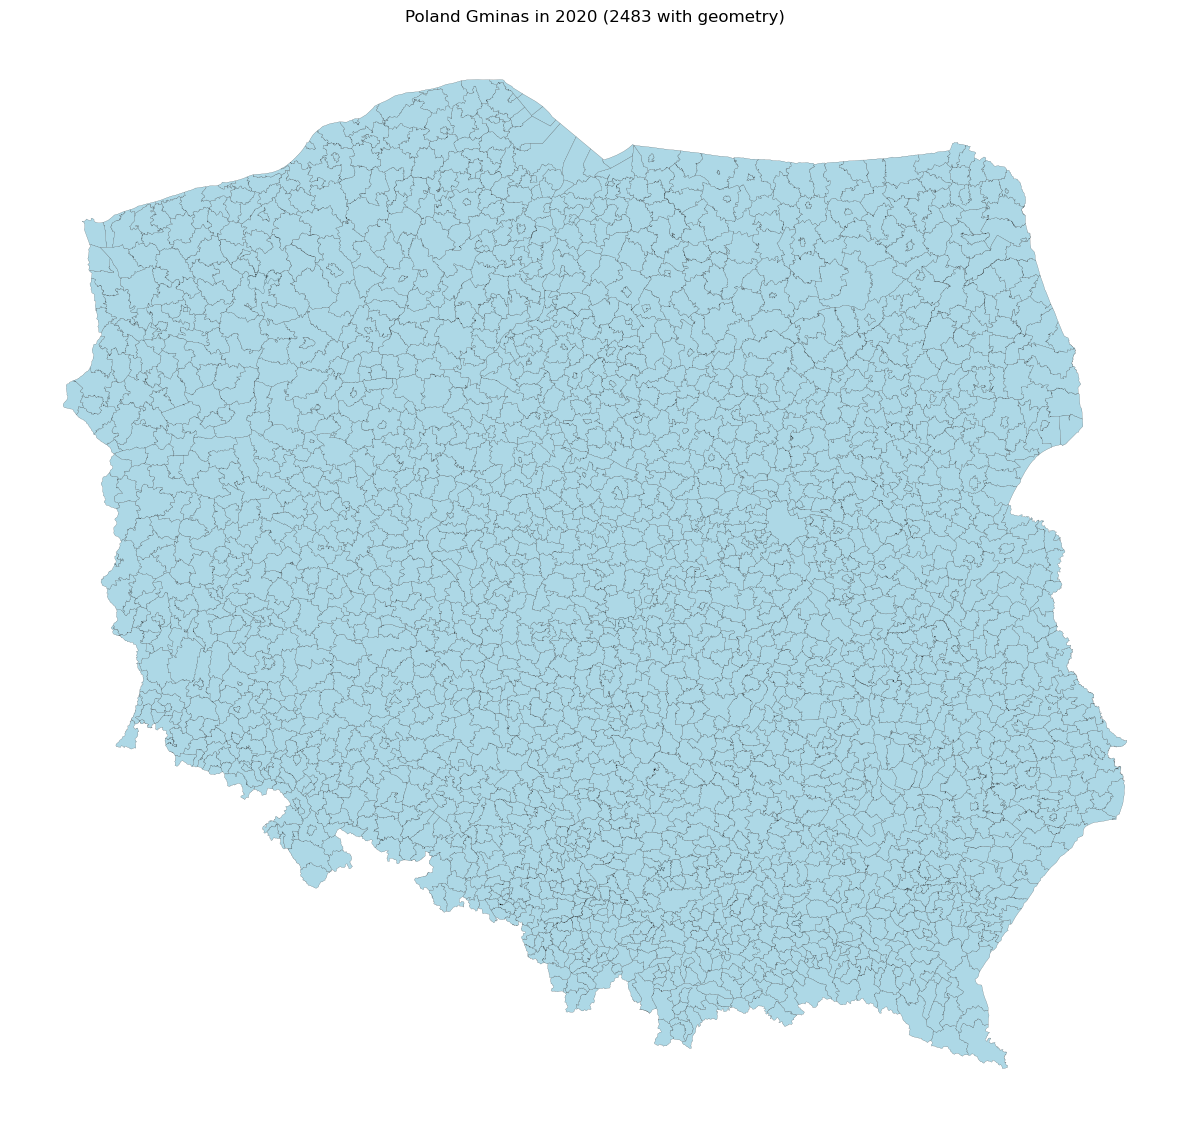

In [ ]:
# Plot gminas with geometry
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_valid = gdf_2020[gdf_2020.geometry.notna()]
gdf_valid.plot(ax=ax, edgecolor='black', linewidth=0.1, facecolor='lightblue')
ax.set_title(f'Poland Gminas in 2020 ({len(gdf_valid)} with geometry)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Voivodeships (merged): 16


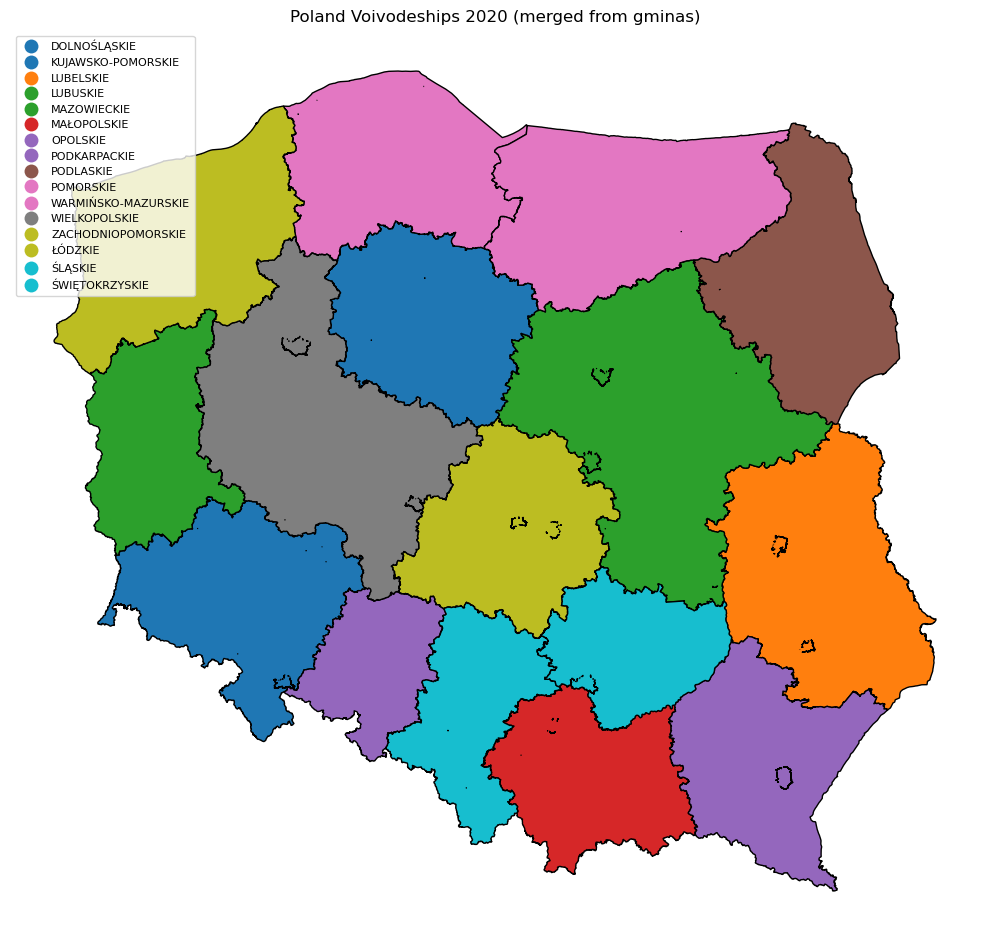

In [ ]:
# Merge to voivodeship level
voivodeships_2020 = db.merge_to_level(year=2020, target_level=2)

print(f"Voivodeships (merged): {len(voivodeships_2020)}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
voivodeships_2020.plot(ax=ax, edgecolor='black', linewidth=1, 
                        column='name', legend=True, legend_kwds={'loc': 'upper left', 'fontsize': 8})
ax.set_title('Poland Voivodeships 2020 (merged from gminas)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Powiats (merged): 380


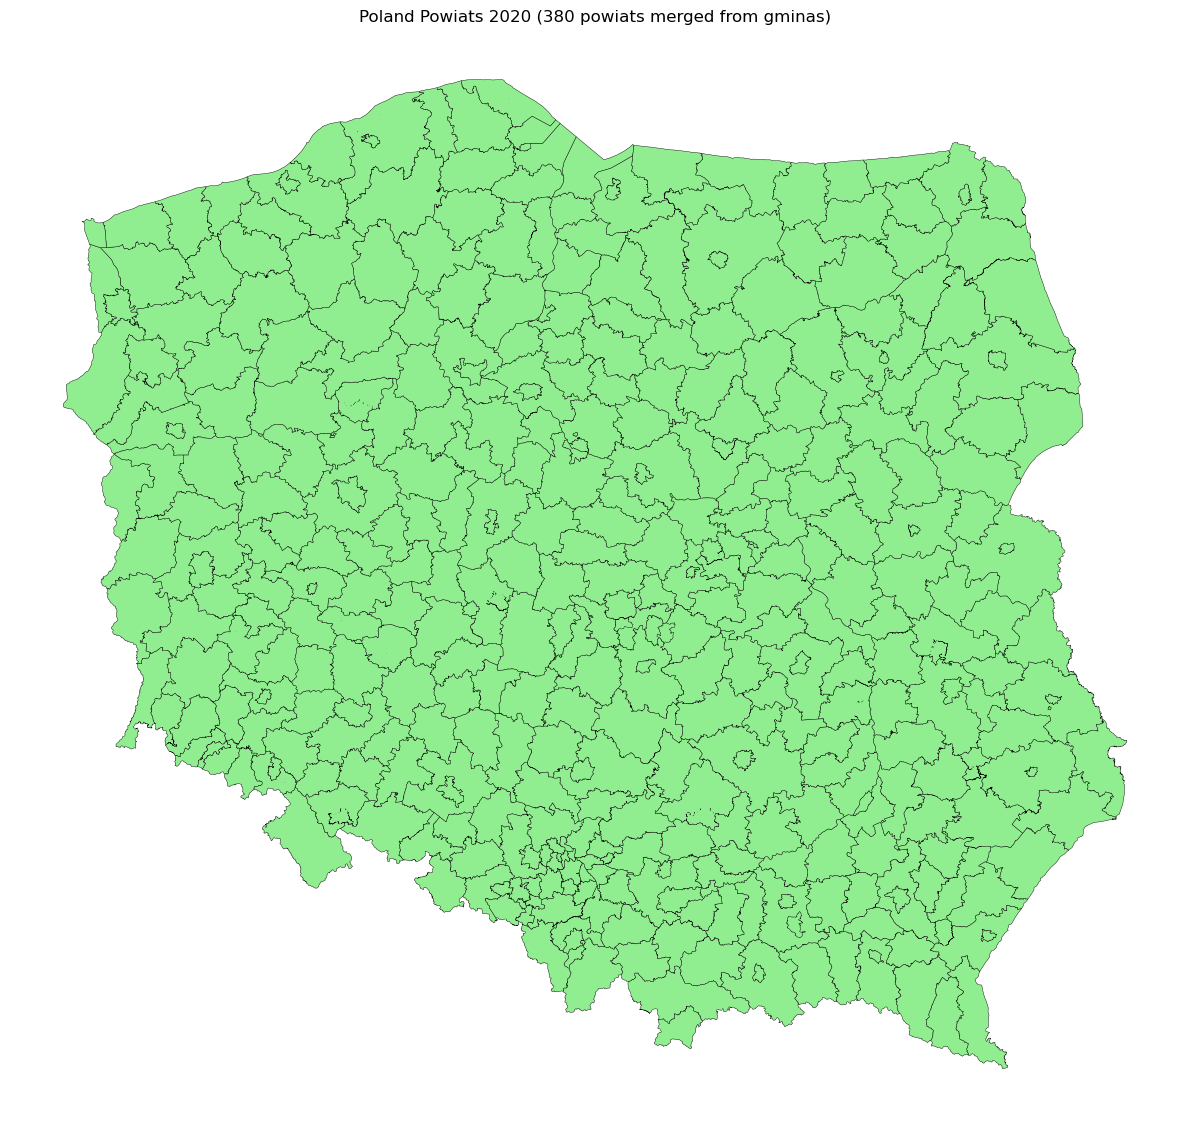

In [ ]:
# Merge to powiat level
powiats_2020 = db.merge_to_level(year=2020, target_level=5)

print(f"Powiats (merged): {len(powiats_2020)}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
powiats_2020.plot(ax=ax, edgecolor='black', linewidth=0.3, facecolor='lightgreen')
ax.set_title(f'Poland Powiats 2020 ({len(powiats_2020)} powiats merged from gminas)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Compare Years

In [ ]:
# Compare gmina counts across years
years_to_compare = [1999, 2005, 2010, 2015, 2020, 2024]
counts = []

for year in years_to_compare:
    stats = db.get_year_statistics(year)
    gminas = stats['level_counts'].get(6, 0)
    powiats = stats['level_counts'].get(5, 0)
    voivodeships = stats['level_counts'].get(2, 0)
    counts.append({
        'year': year,
        'gminas': gminas,
        'powiats': powiats,
        'voivodeships': voivodeships
    })

counts_df = pd.DataFrame(counts)
print(counts_df.to_string(index=False))

 year  gminas  powiats  voivodeships
 1999    3649      373            16
 2005    3675      379            16
 2010    3710      379            16
 2015    3737      380            16
 2020    3800      380            16
 2024    3938      380            16


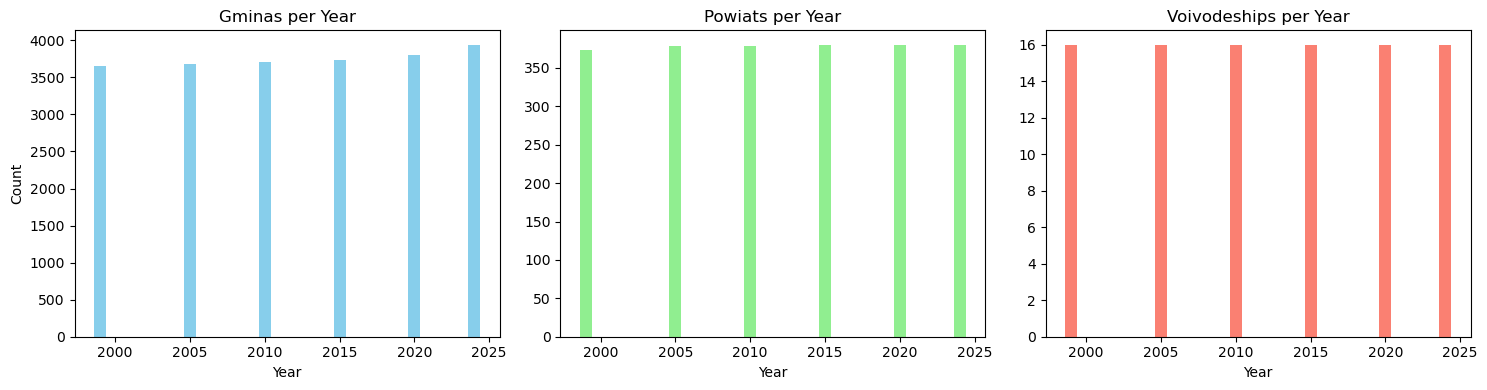

In [ ]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(counts_df['year'], counts_df['gminas'], color='skyblue')
axes[0].set_title('Gminas per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

axes[1].bar(counts_df['year'], counts_df['powiats'], color='lightgreen')
axes[1].set_title('Powiats per Year')
axes[1].set_xlabel('Year')

axes[2].bar(counts_df['year'], counts_df['voivodeships'], color='salmon')
axes[2].set_title('Voivodeships per Year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

## 7. Export Database

In [ ]:
# Export to DataFrame
db_df = db.to_dataframe(include_geometry=False)
print(f"Exported {len(db_df)} records to DataFrame")
db_df.head()

Exported 4560 records to DataFrame


,teryt_id,name,name_dod,level,kind,woj,pow,gmi,rodz,years_valid,...,last_year,past_names,past_teryt_ids,past_levels,past_kinds,changes,has_changes,n_changes,has_geometry,geometry_year
0,0200000,DOLNOŚLĄSKIE,województwo,2,NaN,02,00,00,0,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,2024,[],[],[],[],[],False,0,False,NaN
1,0201000,bolesławiecki,powiat,5,NaN,02,01,00,0,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,2024,[],[],[],[],[],False,0,False,NaN
2,0201011,Bolesławiec,gmina miejska,6,urban,02,01,01,1,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,2024,[],[],[],[],[],False,0,True,2023.0
3,0201022,Bolesławiec,gmina wiejska,6,rural,02,01,02,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,2024,[],[],[],[],[],False,0,True,2023.0
4,0201032,Gromadka,gmina wiejska,6,rural,02,01,03,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,2024,[],[],[],[],[],False,0,True,2023.0


In [ ]:
# Save to CSV
output_path = geospatial_root / "geoteryt_database.csv"
db_df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Saved to {output_path}")

Saved to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_database.csv


In [ ]:
# Export specific year to GeoPackage (if geopandas supports it)
try:
    output_gpkg = geospatial_root / "gminas_2020.gpkg"
    db.export_to_geopackage(output_gpkg, year=2020, level=6)
    print(f"Exported 2020 gminas to {output_gpkg}")
except Exception as e:
    print(f"GeoPackage export not available: {e}")

Exported 2020 gminas to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gminas_2020.gpkg


## 8. Summary

The GeoTERYT database has been successfully built and tested. Key capabilities:

1. **Data Storage**: All administrative divisions from 1999-2024
2. **Historical Tracking**: Name changes, ID changes, structural changes
3. **Geometry Integration**: Multiple shapefile sources linked to records
4. **Search**: By TERYT ID, name, year, level, kind
5. **Geometry Operations**: Merge to higher levels, best geometry selection
6. **Export**: DataFrame, CSV, GeoPackage, Shapefile

## Testing Database v2.0 Fixes\n\nThe database has been rewritten to fix the following issues:\n1. **Change tracking**: Notes column is now properly parsed from CSV strings\n2. **Level changes**: Now tracks `past_levels` for units that changed level\n3. **Kind changes**: Now tracks `past_kinds` for units that changed kind\n4. **get_changed_units()**: Now properly returns changed units\n5. **Geometry clipping**: Can now clip geometries to Poland boundary

In [ ]:
# Reload the module to get the fixed version
import importlib
import sys
from pathlib import Path

# Add the tools directory to path if not already there
tools_path = Path.cwd().parent / "tools"
if str(tools_path) not in sys.path:
    sys.path.insert(0, str(tools_path))

# Remove old module from cache if present
for mod_name in list(sys.modules.keys()):
    if 'geoTERYT' in mod_name:
        del sys.modules[mod_name]

# Import fresh
import geoTERYT_db as gdb
importlib.reload(gdb)
from geoTERYT_db import GeoTERYTDatabase, TERYTRecord, parse_notes_column
print("✓ Loaded geoTERYT_db v2.0")

✓ Loaded geoTERYT_db v2.0


In [ ]:
# Test 1: Verify notes column parsing works correctly
# Check a sample row from mega_df
sample_row = mega_df[mega_df['if_changed'] == True].iloc[0] if (mega_df['if_changed'] == True).any() else mega_df.iloc[0]
print("Sample notes value type:", type(sample_row.get('notes')))
print("Sample notes value:", sample_row.get('notes')[:200] if isinstance(sample_row.get('notes'), str) else sample_row.get('notes'))
print()

# Test parsing
parsed = parse_notes_column(sample_row.get('notes'))
print("Parsed notes:", parsed)
print("Number of changes:", parsed.get('number_of_changes', 0))

Sample notes value type: <class 'str'>
Sample notes value: {'number_of_changes': 1, 'changes': ['TYPE_CHANGE: rural -> urban-rural', 'DESIGNATION_CHANGE: gmina wiejska -> gmina miejsko-wiejska']}

Parsed notes: {'number_of_changes': 1, 'changes': ['TYPE_CHANGE: rural -> urban-rural', 'DESIGNATION_CHANGE: gmina wiejska -> gmina miejsko-wiejska']}
Number of changes: 1


In [ ]:
# Test 2: Rebuild database with fixed code
db2 = GeoTERYTDatabase()
db2.build_from_harmonized(mega_df, verbose=True)

Building GeoTERYT database v2.0 from harmonized data...
  Pass 1: Collecting unit states by year...
    Found 4560 unique TERYT IDs across all years
  Pass 2: Building records with change detection...
    Name changes detected: 33
    Kind changes detected: 0
    Level changes detected: 0
    Changes from notes: 1606
  Pass 3: Building indices...

✓ Database built successfully!
  Total records: 4,560
  Year range: 1999 - 2024
  Voivodeships: 16
  Powiats: 382
  Gminas: 4162
  Units with changes: 773
  Units with level changes: 0
  Units with kind changes: 0


In [ ]:
# Test 3: Check Tyszowce (0618123) - should now have changes
tyszowce = db2.get_by_teryt_id("0618123")
if tyszowce:
    print(f"Tyszowce ({tyszowce.teryt_id}):")
    print(f"  Name: {tyszowce.name}")
    print(f"  Kind: {tyszowce.kind}")
    print(f"  Level: {tyszowce.level}")
    print(f"  Years valid: {min(tyszowce.years_valid)}-{max(tyszowce.years_valid)}")
    print(f"  has_changes: {tyszowce.has_changes}")
    print(f"  Number of changes: {tyszowce.n_changes}")
    print(f"  Changes: {tyszowce.changes}")
    print(f"  Past names: {tyszowce.past_names}")
    print(f"  Past kinds: {tyszowce.past_kinds}")  
    print(f"  Past levels: {tyszowce.past_levels}")
else:
    print("Tyszowce not found!")

Tyszowce (0618123):
  Name: Tyszowce
  Kind: urban-rural
  Level: 6
  Years valid: 2000-2024
  has_changes: True
  Number of changes: 2
  Changes: [{'year': np.int64(2000), 'type': 'reform', 'description': 'TYPE_CHANGE: rural -> urban-rural', 'when_changed': 2000.0}, {'year': np.int64(2000), 'type': 'reform', 'description': 'DESIGNATION_CHANGE: gmina wiejska -> gmina miejsko-wiejska', 'when_changed': 2000.0}]
  Past names: []
  Past kinds: []
  Past levels: []


In [ ]:
# Test 4: get_changed_units() should now return results
changed_2015_2020 = db2.get_changed_units(year_from=2015, year_to=2020)
print(f"Units with changes between 2015-2020: {len(changed_2015_2020)}")
print()

# Show first 10 examples
for i, unit in enumerate(changed_2015_2020[:10]):
    print(f"  {unit.teryt_id} - {unit.name}: {unit.n_changes} changes")
    for change in unit.changes[:2]:
        print(f"    - {change}")

Units with changes between 2015-2020: 109

  0417052 - Ryńsk: 11 changes
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'TYPE_CHANGE: rural -> nan', 'when_changed': nan}
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'NAME_CHANGE: Wąbrzeźno -> Ryńsk', 'when_changed': nan}
  1210022 - Chełmiec: 8 changes
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'TYPE_CHANGE: rural -> urban-rural', 'when_changed': nan}
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'DESIGNATION_CHANGE: gmina wiejska -> gmina miejsko-wiejska', 'when_changed': nan}
  2605062 - Słupia Konecka: 11 changes
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'TYPE_CHANGE: rural -> nan', 'when_changed': nan}
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'NAME_CHANGE: Słupia (Konecka) -> Słupia Konecka', 'when_changed': nan}
  3214011 - Stargard: 11 changes
    - {'year': np.int64(1999), 'type': 'reform', 'description': 'TYPE_

In [ ]:
# Test 5: Check units with level changes (new feature!)
level_changed = db2.get_units_with_level_changes()
print(f"Units with level changes: {len(level_changed)}")
for unit in level_changed[:10]:
    print(f"  {unit.teryt_id} - {unit.name}")
    print(f"    Current level: {unit.level}")
    print(f"    Past levels: {unit.past_levels}")

Units with level changes: 0


In [ ]:
# Test 6: Check units with kind changes (urban/rural transitions)
kind_changed = db2.get_units_with_kind_changes()
print(f"Units with kind changes: {len(kind_changed)}")
for unit in kind_changed[:10]:
    print(f"  {unit.teryt_id} - {unit.name}")
    print(f"    Current kind: {unit.kind}")
    print(f"    Past kinds: {unit.past_kinds}")

Units with kind changes: 0


In [ ]:
# Test 7: Load geometries and check Poland boundary clipping
# First load Poland boundary from GADM
gadm_path = geospatial_root / "gadm41_POL_shp" / "gadm41_POL_0.shp"
if gadm_path.exists():
    db2.load_poland_boundary(gadm_path)
else:
    print(f"GADM file not found at {gadm_path}")
    # Try to find it
    for p in geospatial_root.rglob("gadm*_0.shp"):
        print(f"  Found: {p}")

# Load geometries with clipping enabled
db2.load_geometries(gdf_list, clip_to_poland=True)

Loading Poland boundary from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gadm41_POL_shp/gadm41_POL_0.shp...
  ✓ Poland boundary loaded and set for clipping
Loading geometries into database...
  (Clipping to Poland boundary enabled)
  Processing 2005_Obszary (year 2005)...
    Linked 34 geometries
  Processing 2006_Obszary (year 2006)...
    Linked 36 geometries
  Processing 2007_Obszary (year 2007)...
    Linked 36 geometries
  Processing 2008_Obszary (year 2008)...
    Linked 36 geometries
  Processing 2009_Obszary (year 2009)...
    Linked 36 geometries
  Processing 2010_Obszary (year 2010)...
    Linked 36 geometries
  Processing 2011_Obszary (year 2011)...
    Linked 36 geometries
  Processing 2012_Obszary_1992_region (year 2012)...
    Linked 36 geometries
  Processing 2015_gminy (year 2015)...
    Linked 2478 geometries
  Processing 2016_gminy (year 2016)...
    Linked 2478 geometries
  Processing

In [ ]:
# Test 8: Print summary of the new database
db2.print_summary()

GeoTERYT Database Summary (v2.0)
Total records:           4,560
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      773
  Records with level changes: 0
  Records with kind changes:  0
------------------------------------------------------------
Geometry:
  Records with geometry: 2555
  Geometry years:        [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  Poland boundary set:   True


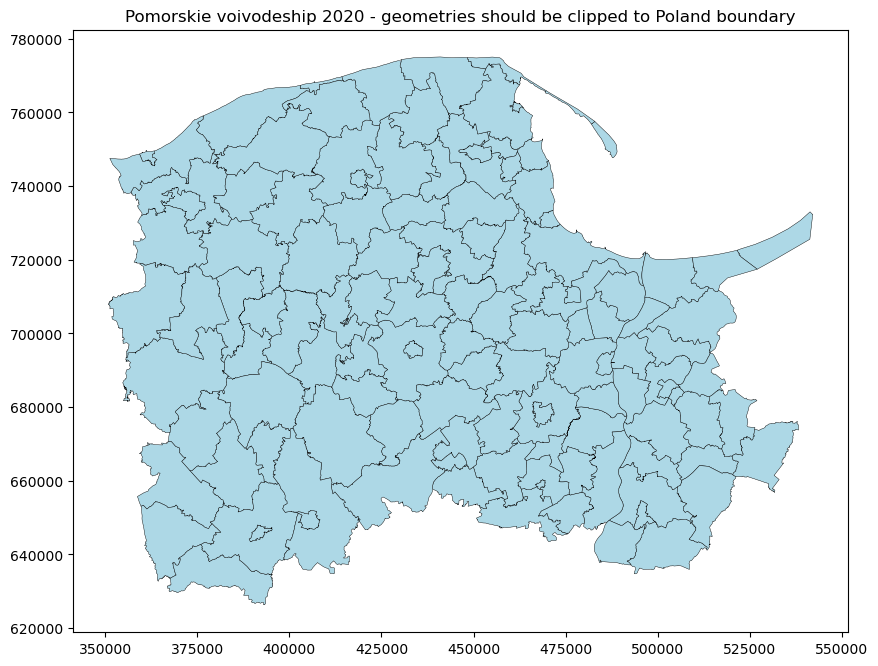

In [ ]:
# Test 9: Visual comparison - check if Hel Peninsula water is clipped
import matplotlib.pyplot as plt

# Get gminas from pomorskie voivodeship (22) for year 2020
gdf_test = db2.to_geodataframe(year=2020, level=6, only_with_geometry=True)
gdf_pom = gdf_test[gdf_test['woj'] == '22']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf_pom.plot(ax=ax, edgecolor='black', linewidth=0.3, facecolor='lightblue')
ax.set_title("Pomorskie voivodeship 2020 - geometries should be clipped to Poland boundary")
plt.show()